# Transit + Occultation fitting for multiple instruments

In previous notebook (`single_instrument.ipynb`), we demonstrated `juliet`'s ability to fit occultation, and a joint transit+occultation model for one instrument. We can fit these models simultaneously for multiple instruments. Depending on the wavelength ranges of different instrument bandpasses, some planetary parameters, such as the Rp/R*, occultation depth, and limb-darkening coefficients, can change for different instruments. At the same time, all other planetary parameters will remain the same for all instruments. `juliet` can handle this pretty well. The limb-darkening coefficients are already instrumental parameters, so, you can share them over several instruments.

Since `juliet` v2.2.5, Rp/R* (`p`) and occultation depth (`fp`) have became planetary _and_ instrumental parameters. That means that we can now also share `p` and `fp` over multiple instruments. Formally, the naming convention is first to specify the planet name (e.g., `p1`) and then instrument name (e.g., `TESS`): we can write them as `p_p1_instrument1_instrument2` or `fp_p1_instrument1` etc. Note that we can choose _not_ to specify instrument name for both `p` and `fp` (i.e., just `p_p1` and `fp_p1`). In this case, `juliet` will assign the same parameter for all instruments (back-compatibility).

This feature of `juliet` is helpful in fitting wavelength dependence of transit and/or occultation depths. For example, while fitting for transmission/emission spectroscopy data, we can give different transit/occultation depth (+ limb-darkening coefficients when needed) for each wavelength bin, but the other planetary parameters can remain the same for each bin. When analysing photometric light curves from various bandpasses, such as CHEOPS and TESS, we may want to give the same transit depths, but different occultation depths for those bandpasses (as we demonstrate in this notebook).

This notebook demonstrate the capability of `juliet` to fit multiple dataset in this regard.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotstyles
import juliet
import os

## I have MacBook Pro with M1 chip, so I need following two lines for multiprocessing to work
import multiprocessing
multiprocessing.set_start_method('fork')

print('juliet version:', juliet.__version__)

juliet version: 2.2.9


We will use CHEOPS and TESS observations of WASP-76 system to demonstrate transit+occultation model fitting over multiple instruments. Our dataset includes 3 CHEOPS observations (Visit 601, 15201, and 15202, published in [Demangeon et al. 2024](https://ui.adsabs.harvard.edu/abs/2024A%26A...684A..27D/abstract)). Out of these three observations, two (Visit 15201 and 15202) contain only occultations, while the third one (Visit 601) contain a full phase curve. However, we will not fit any out-of-transit/occultation variations (i.e., phase curve) in this tutorial. Please see other notebooks for phase curve fitting.

The TESS observation used in this notebook is from Sector 43. All the data products are already downloaded and saved in Data folder.

Let's first load some planetary parameters from the literature.

In [2]:
# And priros
## We need planetary and stellar parameters for this (all parameters are from Ehrenreich et al. 2020)
per, per_err = 1.80988198, np.sqrt(0.00000064**2 + 0.00000056**2)           # Orbital period in days
t0, t0_err = 2458080.626165, np.sqrt(0.000418**2 + 0.000367**2)             # Transit epoch in BJD
rprs, rprs_err = 0.10852, np.sqrt(0.00096**2 + 0.00072**2)                  # Planet-to-star radius ratio
b, b_err = 0.0270, np.sqrt(0.1300**2 + 0.0230**2)                           # Impact parameter
rho, rho_err = 379.39, 47.35                                                # Stellar density in kg/m3

Now, let's load and plot the dataset:

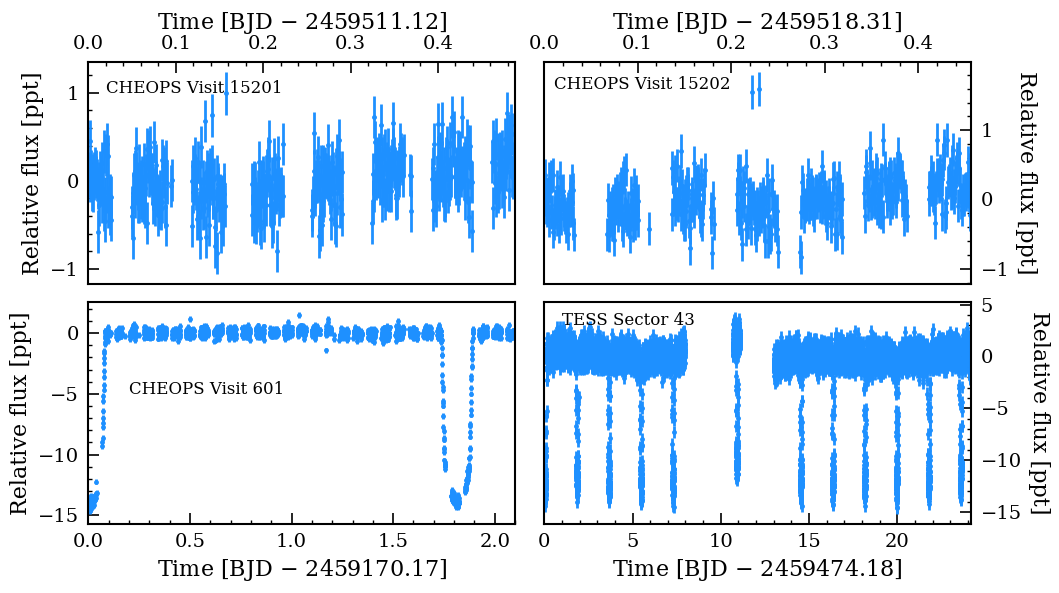

In [3]:
# CHEOPS data
## CHEOPS Visit 601
tim601, fl601, fle601 = np.loadtxt(os.getcwd() + '/Data/WASP-76_CHEOPS601.dat', usecols=(0,1,2), unpack=True)
## CHEOPS Visit 15201
tim15201, fl15201, fle15201 = np.loadtxt(os.getcwd() + '/Data/WASP-76_CHEOPS15201.dat', usecols=(0,1,2), unpack=True)
## CHEOPS Visit 15202
tim15202, fl15202, fle15202 = np.loadtxt(os.getcwd() + '/Data/WASP-76_CHEOPS15202.dat', usecols=(0,1,2), unpack=True)

# TESS data
tim43, fl43, fle43 = np.loadtxt(os.getcwd() + '/Data/WASP-76_TESS43.dat', usecols=(0,1,2), unpack=True)


# Ploting the data
fig, axs = plt.subplots(nrows=2, ncols=2)
axs[0, 0].errorbar(tim15201-tim15201[0], ( fl15201 - 1. )*1e3, yerr=fle15201*1e3, fmt='.', color='dodgerblue' )
axs[0, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim15201[0]))
axs[0, 0].set_ylabel('Relative flux [ppt]')
axs[0, 0].text(0.02, 1., 'CHEOPS Visit 15201', fontsize=12, color='k')
axs[0, 0].set_xlim([0., np.max(tim15201-tim15201[0])])

axs[0, 0].xaxis.tick_top()
axs[0, 0].xaxis.set_label_position('top')

axs[0, 1].errorbar(tim15202-tim15202[0], ( fl15202 - 1. )*1e3, yerr=fle15202*1e3, fmt='.', color='dodgerblue' )
axs[0, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim15202[0]))
axs[0, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[0, 1].text(0.01, 1.6, 'CHEOPS Visit 15202', fontsize=12, color='k')
axs[0, 1].set_xlim([0., np.max(tim15202-tim15202[0])])

axs[0, 1].xaxis.tick_top()
axs[0, 1].xaxis.set_label_position('top')
axs[0, 1].yaxis.tick_right()
axs[0, 1].yaxis.set_label_position('right')

axs[1, 0].errorbar(tim601-tim601[0], ( fl601 - 1. )*1e3, yerr=fle601*1e3, fmt='.', color='dodgerblue' )
axs[1, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim601[0]))
axs[1, 0].set_ylabel('Relative flux [ppt]')
axs[1, 0].text(0.2, -5., 'CHEOPS Visit 601', fontsize=12, color='k')
axs[1, 0].set_xlim([0., np.max(tim601-tim601[0])])

axs[1, 1].errorbar(tim43-tim43[0], ( fl43 - 1. )*1e3, yerr=fle43*1e3, fmt='.', color='dodgerblue' )
axs[1, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim43[0]))
axs[1, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[1, 1].text(1., 3., 'TESS Sector 43', fontsize=12, color='k')
axs[1, 1].set_xlim([0., np.max(tim43-tim43[0])])

axs[1, 1].yaxis.tick_right()
axs[1, 1].yaxis.set_label_position('right')

plt.tight_layout()

So, we have 4 instruments. Among them, two (CHEOPS15201 and CHEOPS15202) only have occultations and two (CHEOPS601 and TESS43) have both transits and occultations. For the former we want to fit occultation only model, while we want to fit a joint transit+occultation model for the latter. Finally, the occultation depth would be the same for all three CHEOPS observations, but it will be different for the TESS observation. However, since the TESS and CHEOPS bandpasses are not very much different, we can expect almost same transit depth between both bandpasses. We will provide the following priors in the fitting to specify all these:

- One single occultation depth parameter for all CHEOPS observations: `fp_p1_CHEOPS601_CHEOPS15201_CHEOPS15202`. This shows that occultation models will be fitted for all CHEOPS observations, and the same occultation depth is to be fitted for all CHEOPS observations.
- One occultation depth parameter for TESS observations: `fp_p1_TESS43`. This will fit an occultation model for TESS observations. The occultation depth would be different from CHEOPS observations.
- One Rp/R* for all observations: `p_p1`. This will fit the same Rp/R* for all CHEOPS and TESS observations.
- Limb-darkening coefficient for CHEOPS observation 601: `q1_CHEOPS601` and `q2_CHEOPS601`. This will fit a transit model, in addition to the occultation model, for CHEOPS observation 601. We will not provide limb-darkening coefficients for other CHEOPS observations since we don't want to fit transit models for them as there are no transits in those observations.
- Limb-darkening coefficients for TESS: `q1_TESS43` and `q2_TESS43`. Again, this will fit a join transit+occultataion model for TESS observation.
- Occultation time: we will _not_ provide any prior for occultation time. So, we need to self-consistently calculate within `juliet`. To achieve this, we will set `light_travel_delay=True` in `juliet.fit`. 
- Eccentricity and argument of periastron: `sesinomega_p1`, `secosomega_p1`. Since we are already calculating occultation time self-consistently, we can use it to constrain eccentricity and argument of periastron. We will do this by providing priors on `sesinomega_p1` and `secosomega_p1`.
- Noise model: both CHEOPS and TESS observations have some additional noise, that can come from either the star of the instrument. For the purpose of this tutorial, we will simply model the noise with a Gaussian process (GP) model. We will use two separate GP models: one for CHEOPS observations and one for the TESS observation. We will use a simple harmonic oscillator (SHO) kernel to generate GP models.

So, let's get started by saving the data and providing priors.

In [4]:
# Instrument name
instruments = ['CHEOPS601', 'CHEOPS15201', 'CHEOPS15202', 'TESS43']

# Creating data dictionaries the way juliet understands
tim, fl, fle = {}, {}, {}
tim['CHEOPS601'], fl['CHEOPS601'], fle['CHEOPS601'] = tim601, fl601, fle601
tim['CHEOPS15201'], fl['CHEOPS15201'], fle['CHEOPS15201'] = tim15201, fl15201, fle15201
tim['CHEOPS15202'], fl['CHEOPS15202'], fle['CHEOPS15202'] = tim15202, fl15202, fle15202
tim['TESS43'], fl['TESS43'], fle['TESS43'] = tim43, fl43, fle43

### Predicting transit and occultation time for our observations
cycle = round((tim15201[0] - t0) / per)
tc, tc_err = t0 + cycle*per, np.sqrt(t0_err**2 + (cycle*per_err)**2)
tsec, tsec_err = tc + (per/2), np.sqrt(tc_err**2 + per_err**2)

# Designing priors
## Planetary parameters
par_P = ['P_p1', 't0_p1', 'p_p1', 'b_p1', 'q1_CHEOPS601', 'q2_CHEOPS601', 'q1_TESS43', 'q2_TESS43', 'rho']
dist_P = ['normal', 'normal', 'normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'normal']
hyper_P = [[per, per_err], [tc, tc_err], [rprs, 3*rprs_err], [b, 3*b_err], [0., 1.], [0., 1.], [0., 1.], [0., 1.], [rho, rho_err]]
## Occultation depth
par_fp = ['fp_p1_CHEOPS601_CHEOPS15201_CHEOPS15202', 'fp_p1_TESS43']
dist_fp = ['uniform', 'uniform']
hyper_fp = [[0., 1000.e-6], [0., 1000.e-6]]
## Eccentricity and argument of periastron
par_ecc = ['sesinomega_p1', 'secosomega_p1']
dist_ecc = ['uniform', 'uniform']
hyper_ecc = [[-0.3, 0.3], [-0.3, 0.3]]

## Instrumental priors
par_ins, dist_ins, hyper_ins = [], [], []
for ins in range(len(instruments)):
    par_ins = par_ins + ['mdilution_' + instruments[ins], 'mflux_' + instruments[ins], 'sigma_w_' + instruments[ins]]
    dist_ins = dist_ins + ['fixed', 'normal', 'loguniform']
    hyper_ins = hyper_ins + [1.0, [0., 0.1], [0.1, 10000]]

## GP priors (for CHEOPS)
par_gp_cheops = ['GP_S0_CHEOPS601_CHEOPS15201_CHEOPS15202', 'GP_omega0_CHEOPS601_CHEOPS15201_CHEOPS15202', 'GP_Q_CHEOPS601_CHEOPS15201_CHEOPS15202']
dist_gp_cheops = ['uniform', 'uniform', 'fixed']
hyper_gp_cheops = [[np.exp(-30.), np.exp(-15.)], [2*np.pi/10, 2*np.pi/0.1], 1/np.sqrt(2)]
### (for TESS)
par_gp_tess = ['GP_S0_TESS43', 'GP_omega0_TESS43', 'GP_Q_TESS43']
dist_gp_tess = ['uniform', 'uniform', 'fixed']
hyper_gp_tess = [[np.exp(-30.), np.exp(-15.)], [2*np.pi/10, 2*np.pi/0.1], 1/np.sqrt(2)]

# Total priors
par_tot = par_P + par_fp + par_ecc + par_ins + par_gp_cheops + par_gp_tess
dist_tot = dist_P + dist_fp + dist_ecc + dist_ins + dist_gp_cheops + dist_gp_tess
hyper_tot = hyper_P + hyper_fp + hyper_ecc + hyper_ins + hyper_gp_cheops + hyper_gp_tess

priors = juliet.utils.generate_priors(params=par_tot, dists=dist_tot, hyperps=hyper_tot)

And `juliet` fitting:

In [5]:
# Output folder
pout = os.getcwd() + '/Analysis/TraEcl_MultiIns'

# Juliet fitting
data = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle,\
                   GP_regressors_lc=tim, out_folder=pout)
res = data.fit(sampler='dynamic_dynesty', nthreads=8, light_travel_delay=True, stellar_radius=1.756)

45661it [1:14:32, 10.21it/s, batch: 2 | bound: 4 | nc: 1 | ncall: 1960842 | eff(%):  2.303 | loglstar: 101012.984 < 101019.909 < 101013.853 | logz: 100948.950 +/-  0.322 | stop:  0.977]     


Now, let's plot the fitted models, so that we can see the results. For this, we need to generate fitted models, detrended models and data from the fitting. We will first do this for all instruments:

In [6]:
# Let's create dicts to save all models and data for each instruments
## For full models
fulll_models_all_ins, rand_models_all_ins = {}, {}
## Detrended and binned data
detrended_phs_all_ins, detrended_data_all_ins, detrended_errs_all_ins = {}, {}, {}
### Detrended models
detrended_models_all_ins, detrended_rand_models_all_ins = {}, {}

# Planetary parameters
P_post = np.nanmedian( res.posteriors['posterior_samples']['P_p1'] )
tc_post = np.nanmedian( res.posteriors['posterior_samples']['t0_p1'] )
fp_post_cheops = np.nanmedian( res.posteriors['posterior_samples']['fp_p1_CHEOPS601_CHEOPS15201_CHEOPS15202'] )

for ins in range(len(instruments)):
    instrument = instruments[ins]
    print('Working on ' + str(instrument) + '...')
    # --------------------------------------------
    #    Some planetary models
    # --------------------------------------------
    ## Mflux and sigma_w (white noise)
    mflx = res.posteriors['posterior_samples']['mflux_' + instrument]
    sigw = np.nanmedian(res.posteriors['posterior_samples']['sigma_w_' + instrument] * 1e-6)

    # --------------------------------------------
    #    Extracting all models
    # --------------------------------------------
    # Creating all models
    model = res.lc.evaluate(instrument, nsamples=5000, return_err=True, return_components=True, return_samples=True)
    ## Saving all models
    all_models = res.lc.model[instrument]

    # --------------------------------------------
    #    Full fitted models
    # --------------------------------------------
    # Full fitted model:
    fulll_models_all_ins[instrument] = model[1]
    ## Sample random full model (to show uncertainties)
    sample_models = model[0]
    idx_nsamps = np.random.choice( np.arange(sample_models.shape[0]), size=100, replace=False)
    rand_models_all_ins[instrument] = sample_models[idx_nsamps, :]

    # --------------------------------------------
    #    Detrended data
    # --------------------------------------------
    ## GP model
    gp_median_model = all_models['GP']
    ## F1 and F2 factors (F2=0 for this case since mdilution is fixed to 1)
    ## See, juliet paper to find their meanings
    F1 = np.nanmedian( 1 / ( 1 + mflx ) )
    F2 = 0.

    # Orbital phases
    phases = juliet.utils.get_phases(t=tim[instrument], P=P_post, t0=tc_post, phmin=0.8)
    ## Sorting indices according to orbital phases
    idx_phs = np.argsort(phases)
    detrended_phs_all_ins[instrument] = phases[idx_phs]

    # Detrended data and errors
    detrended_data_all_ins[instrument] = ( ( fl[instrument] - gp_median_model ) / F1 )[idx_phs]
    detrended_errs_all_ins[instrument] = ( np.sqrt( fle[instrument]**2 + sigw**2 ) )[idx_phs]

    # --------------------------------------------
    #    Detrended models
    # --------------------------------------------
    # Detrended model (we only want to see changes due to planetary parameters so we will fix other params)
    post_samps_new = res.posteriors['posterior_samples'].copy()
    for i in post_samps_new.keys():
        if ( i[0:5] == 'mflux' ) or ( i[0:9] == 'mdilution' ) or ( i[0:5] == 'theta' ) or ( i[0:2] == 'GP' ):
            post_samps_new[i] = np.zeros(len(post_samps_new[i]))

    planet_only_models = res.lc.evaluate(instrument, nsamples=5000, return_err=True, parameter_values=post_samps_new,\
                                         return_components=True, return_samples=True, evaluate_transit=True)


    # Detrended median model
    detrended_models_all_ins[instrument] = planet_only_models[1][idx_phs]
    ## Random models to show uncertainties
    sample_pl_models = planet_only_models[0][:, idx_phs]
    idx_nsamps_pl = np.random.choice( np.arange(sample_pl_models.shape[0]), size=100, replace=False)
    detrended_rand_models_all_ins[instrument] = sample_pl_models[idx_nsamps_pl, :]

    print('Done!!')

# For binned data points:
binned_phs, binned_data, binned_errs = {}, {}, {}
for ins in range(len(instruments)):
    if instruments[ins][0:6] == 'CHEOPS':
        nbin = 35
    else:
        nbin = 150
    binned_phs[instruments[ins]], binned_data[instruments[ins]], binned_errs[instruments[ins]] = \
        juliet.utils.bin_data(x=detrended_phs_all_ins[instruments[ins]],\
                              y=detrended_data_all_ins[instruments[ins]], n_bin=nbin,\
                              yerr=detrended_errs_all_ins[instruments[ins]])

Working on CHEOPS601...
Done!!
Working on CHEOPS15201...
Done!!
Working on CHEOPS15202...
Done!!
Working on TESS43...
Done!!


Let's first plot the full models...

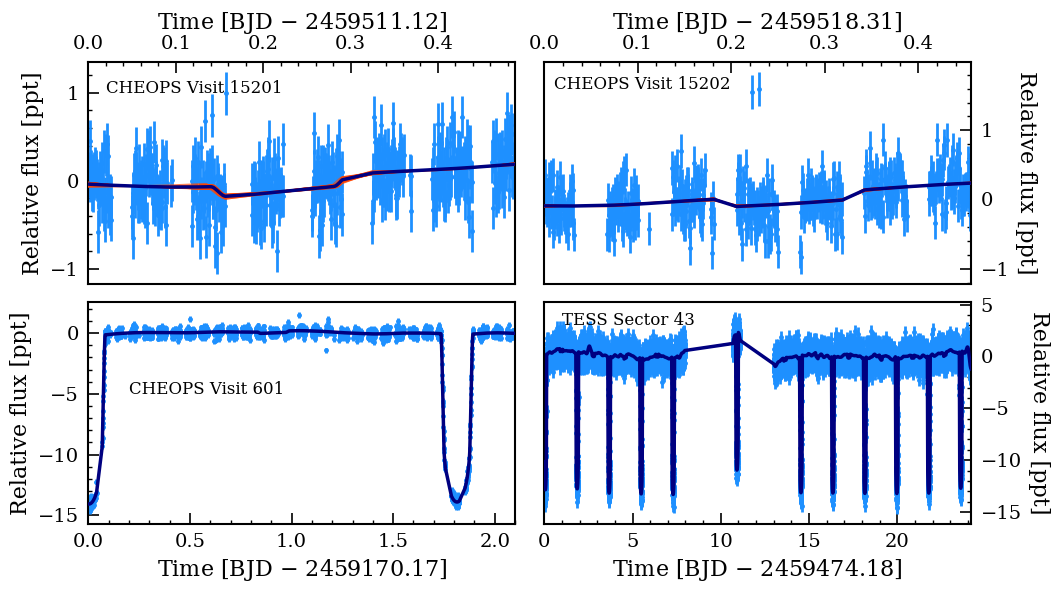

In [7]:
# Ploting the data
fig, axs = plt.subplots(nrows=2, ncols=2)
axs[0, 0].errorbar(tim15201-tim15201[0], ( fl15201 - 1. )*1e3, yerr=fle15201*1e3, fmt='.', color='dodgerblue' )
axs[0, 0].plot(tim15201-tim15201[0], (fulll_models_all_ins['CHEOPS15201'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[0, 0].plot(tim15201-tim15201[0], (rand_models_all_ins['CHEOPS15201'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[0, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim15201[0]))
axs[0, 0].set_ylabel('Relative flux [ppt]')
axs[0, 0].text(0.02, 1., 'CHEOPS Visit 15201', fontsize=12, color='k')
axs[0, 0].set_xlim(0., np.max(tim15201-tim15201[0]))

axs[0, 0].xaxis.tick_top()
axs[0, 0].xaxis.set_label_position('top')

axs[0, 1].errorbar(tim15202-tim15202[0], ( fl15202 - 1. )*1e3, yerr=fle15202*1e3, fmt='.', color='dodgerblue' )
axs[0, 1].plot(tim15202-tim15202[0], (fulll_models_all_ins['CHEOPS15202'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[0, 1].plot(tim15202-tim15202[0], (rand_models_all_ins['CHEOPS15202'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[0, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim15202[0]))
axs[0, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[0, 1].text(0.01, 1.6, 'CHEOPS Visit 15202', fontsize=12, color='k')
axs[0, 1].set_xlim(0., np.max(tim15202-tim15202[0]))

axs[0, 1].xaxis.tick_top()
axs[0, 1].xaxis.set_label_position('top')
axs[0, 1].yaxis.tick_right()
axs[0, 1].yaxis.set_label_position('right')

axs[1, 0].errorbar(tim601-tim601[0], ( fl601 - 1. )*1e3, yerr=fle601*1e3, fmt='.', color='dodgerblue' )
axs[1, 0].plot(tim601-tim601[0], (fulll_models_all_ins['CHEOPS601'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[1, 0].plot(tim601-tim601[0], (rand_models_all_ins['CHEOPS601'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[1, 0].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim601[0]))
axs[1, 0].set_ylabel('Relative flux [ppt]')
axs[1, 0].text(0.2, -5., 'CHEOPS Visit 601', fontsize=12, color='k')
axs[1, 0].set_xlim(0., np.max(tim601-tim601[0]))

axs[1, 1].errorbar(tim43-tim43[0], ( fl43 - 1. )*1e3, yerr=fle43*1e3, fmt='.', color='dodgerblue' )
axs[1, 1].plot(tim43-tim43[0], (fulll_models_all_ins['TESS43'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[1, 1].plot(tim43-tim43[0], (rand_models_all_ins['TESS43'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[1, 1].set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim43[0]))
axs[1, 1].set_ylabel('Relative flux [ppt]', rotation=270, labelpad=20)
axs[1, 1].text(1., 3., 'TESS Sector 43', fontsize=12, color='k')
axs[1, 1].set_xlim(0., np.max(tim43-tim43[0]))

axs[1, 1].yaxis.tick_right()
axs[1, 1].yaxis.set_label_position('right')

plt.tight_layout()

Nice! So, the blue points are the original raw data points. The solid blue line is the median fitted model, while the orange lines show the models calculated from the randomly selected posteriors to demonstrate the uncertainties in the model.

Okay, let's now plot the detrended occultation model,

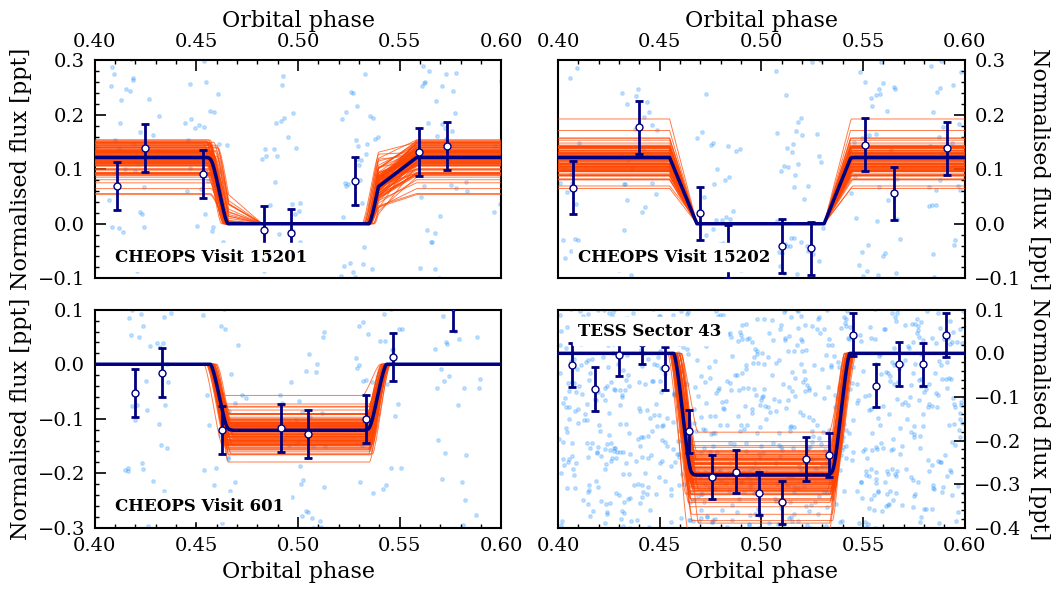

In [8]:
# Ploting the data
fig, axs = plt.subplots(nrows=2, ncols=2)
axs[0, 0].errorbar(detrended_phs_all_ins['CHEOPS15201'], ( detrended_data_all_ins['CHEOPS15201'] - 1. )*1e3, fmt='.', color='dodgerblue', alpha=0.25, zorder=1)
axs[0, 0].errorbar(binned_phs['CHEOPS15201'], (binned_data['CHEOPS15201'] - 1.)*1e3, yerr=binned_errs['CHEOPS15201']*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
axs[0, 0].plot(detrended_phs_all_ins['CHEOPS15201'], (detrended_models_all_ins['CHEOPS15201'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[0, 0].plot(detrended_phs_all_ins['CHEOPS15201'], (detrended_rand_models_all_ins['CHEOPS15201'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[0, 0].set_xlabel('Orbital phase')
axs[0, 0].set_ylabel('Normalised flux [ppt]')
axs[0, 0].text(0.41, -0.07, 'CHEOPS Visit 15201', fontsize=12, backgroundcolor='white', fontweight='bold', color='k', zorder=500)
axs[0, 0].set_xlim([0.4, 0.6])
axs[0, 0].set_ylim([-0.1, 0.3])

axs[0, 0].xaxis.tick_top()
axs[0, 0].xaxis.set_label_position('top')

axs[0, 1].errorbar(detrended_phs_all_ins['CHEOPS15202'], ( detrended_data_all_ins['CHEOPS15202'] - 1. )*1e3, fmt='.', color='dodgerblue', alpha=0.25, zorder=1)
axs[0, 1].errorbar(binned_phs['CHEOPS15202'], (binned_data['CHEOPS15202'] - 1.)*1e3, yerr=binned_errs['CHEOPS15202']*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
axs[0, 1].plot(detrended_phs_all_ins['CHEOPS15202'], (detrended_models_all_ins['CHEOPS15202'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[0, 1].plot(detrended_phs_all_ins['CHEOPS15202'], (detrended_rand_models_all_ins['CHEOPS15202'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[0, 1].set_xlabel('Orbital phase')
axs[0, 1].set_ylabel('Normalised flux [ppt]', rotation=270, labelpad=20)
axs[0, 1].text(0.41, -0.07, 'CHEOPS Visit 15202', fontsize=12, backgroundcolor='white', fontweight='bold', color='k', zorder=500)
axs[0, 1].set_xlim([0.4, 0.6])
axs[0, 1].set_ylim([-0.1, 0.3])

axs[0, 1].xaxis.tick_top()
axs[0, 1].xaxis.set_label_position('top')
axs[0, 1].yaxis.tick_right()
axs[0, 1].yaxis.set_label_position('right')

axs[1, 0].errorbar(detrended_phs_all_ins['CHEOPS601'], ( detrended_data_all_ins['CHEOPS601'] - 1. )*1e3, fmt='.', color='dodgerblue', alpha=0.25, zorder=1)
axs[1, 0].errorbar(binned_phs['CHEOPS601'], (binned_data['CHEOPS601'] - 1.)*1e3, yerr=binned_errs['CHEOPS601']*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
axs[1, 0].plot(detrended_phs_all_ins['CHEOPS601'], (detrended_models_all_ins['CHEOPS601'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[1, 0].plot(detrended_phs_all_ins['CHEOPS601'], (detrended_rand_models_all_ins['CHEOPS601'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[1, 0].set_xlabel('Orbital phase')
axs[1, 0].set_ylabel('Normalised flux [ppt]')
axs[1, 0].text(0.41, -0.27, 'CHEOPS Visit 601', fontsize=12, color='k', fontweight='bold', backgroundcolor='white', zorder=500)
axs[1, 0].set_xlim([0.4, 0.6])
axs[1, 0].set_ylim([-0.3, 0.1])

axs[1, 1].errorbar(detrended_phs_all_ins['TESS43'], ( detrended_data_all_ins['TESS43'] - 1. )*1e3, fmt='.', color='dodgerblue', alpha=0.25, zorder=1)
axs[1, 1].errorbar(binned_phs['TESS43'], (binned_data['TESS43'] - 1.)*1e3, yerr=binned_errs['TESS43']*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
axs[1, 1].plot(detrended_phs_all_ins['TESS43'], (detrended_models_all_ins['TESS43'] - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs[1, 1].plot(detrended_phs_all_ins['TESS43'], (detrended_rand_models_all_ins['TESS43'][rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs[1, 1].set_xlabel('Orbital phase')
axs[1, 1].set_ylabel('Normalised flux [ppt]', rotation=270, labelpad=20)
axs[1, 1].text(0.41, 0.04, 'TESS Sector 43', fontsize=12, color='k', fontweight='bold', backgroundcolor='white', zorder=500)
axs[1, 1].set_xlim(0.4, 0.6)
axs[1, 1].set_ylim(-0.4, 0.1)

axs[1, 1].yaxis.tick_right()
axs[1, 1].yaxis.set_label_position('right')

plt.tight_layout()

The light blue points in above figure are the original unbinned data points, while open blue points are the binned data points. The solid blue line is the fitted median occultation model, while the orange lines show the model calculated from the randomly selected posteriors to demonstrate the uncertainties in the model computation.

A clear occultation signal can be seen in all datasets. Moreover, it is clear that the occultation depth is different for CHEOPS and TESS datasets.

There are several things about the figure that should be discussed. First, the median occultation model (solid blue) for CHEOPS Visit 15201 seems weird in egress -- that's because there is simply no data during egress, so, `plt.plot` simply draw a straight line for that part. That's why it looks unusual. The same thing is also happening for both ingress and egress of CHEOPS Visit 15202.

Second, the model baseline seems to be different for all observations. For example, the baseline (0. flux level in the figure) is during in-occultation for CHEOPS Visits 15201 and 15202. On the other hand, the baseline is set to out-of-occultation times for CHEOPS Visit 601 and TESS Sector 43. The baseline level is set internally in `juliet` to in-occultation and out-of-occultation times for occultation-only fitting and transit+occultation fitting, respectively. I don't think there is any particular reason for this (?), but this is why we are are seeing differences in baseline in above figure. Since baseline level is fixed, the model is also fixed for baseline, and it can be uncertain out of baseline. That is also why the model uncertainties are only there out-of-occultation for CHEOPS Visits 15201 and 15202 (the baseline is in-occultation for both of these visits). Similarly, the model uncertainties are non-zero in-occultation for CHEOPS Visit 601 and TESS Sector 43 (the baseline is out-of-occultation for these observations).

Okay! Let's look at the posteriors of occultation depths:

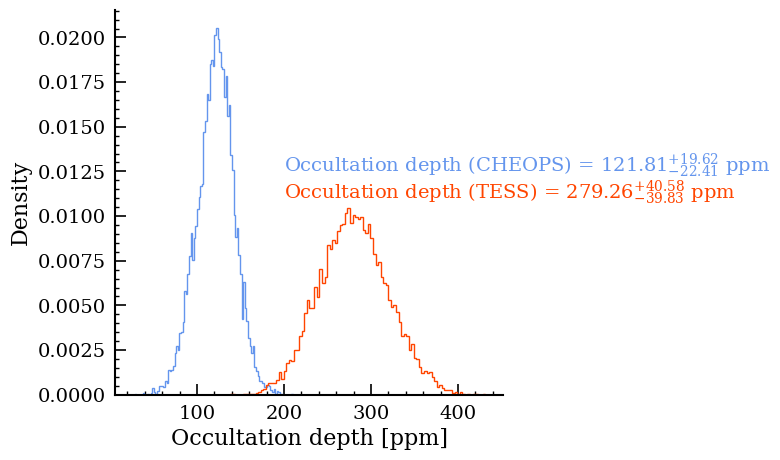

In [9]:
fp_CHEOPS = res.posteriors['posterior_samples']['fp_p1_CHEOPS601_CHEOPS15201_CHEOPS15202']*1e6
fp_TESS = res.posteriors['posterior_samples']['fp_p1_TESS43']*1e6

# Computing the confidence intervals for the occultation depth
## For CHEOPS
qua_c = juliet.utils.get_quantiles(fp_CHEOPS)
fp_med_c, fp_up_c, fp_lo_c = qua_c[0], qua_c[1]-qua_c[0], qua_c[0]-qua_c[2]
## For TESS
qua_t = juliet.utils.get_quantiles(fp_TESS)
fp_med_t, fp_up_t, fp_lo_t = qua_t[0], qua_t[1]-qua_t[0], qua_t[0]-qua_t[2]

fig, axs = plt.subplots(figsize=(5,5))
axs.hist(fp_CHEOPS, color='cornflowerblue', bins=100, histtype='step', density=True);
axs.hist(fp_TESS, color='orangered', bins=100, histtype='step', density=True);
axs.text(200, 0.0125, 'Occultation depth (CHEOPS) = ${' + str(np.around(fp_med_c,2)) + '}_{-' + str(np.around(fp_lo_c,2)) + '}^{+' + str(np.around(fp_up_c,2)) + '}$ ppm', fontsize=14, color='cornflowerblue')
axs.text(200, 0.011, 'Occultation depth (TESS) = ${' + str(np.around(fp_med_t,2)) + '}_{-' + str(np.around(fp_lo_t,2)) + '}^{+' + str(np.around(fp_up_t,2)) + '}$ ppm', fontsize=14, color='orangered')
axs.set_xlabel('Occultation depth [ppm]')
axs.set_ylabel('Density')

sns.despine()

Excellent! The CHEOPS and TESS occultation depths are indeed very different from each other. That is expected since the TESS bandpass is more sensitive towards the redder wavelengths, so we should expect more thermal radiation in TESS bandpass compared to CHEOPS. The values of occultation depths seem to be consistent with their corresponding values reported in [Demangeon et al. 2024](https://ui.adsabs.harvard.edu/abs/2024A%26A...684A..27D/abstract).